# 第 12 章　卷積神經網路（CNN）：讓模型看懂影像 — 實作 Notebook

「醫學生的機器學習入門」深度學習篇第 12 章配套程式。建議在 **Google Colab** 執行（選單「執行階段 → 全部執行」）；本機 Jupyter 也可以，但需要安裝 Keras 3 與 TensorFlow。

- 第 1 節：用 NumPy 親手做一次卷積與池化，看懂 CNN 最基本的運算（不需要 Keras）。
- 第 2–4 節：在胸部 X 光小圖（PneumoniaMNIST）上，把第 9 章的全連接網路和小型 CNN 放在同一份測試集比較，並畫出 CNN 學到的濾鏡與特徵圖。
- 第 5 節（練習，**建議開 GPU，可跳過**）：多類別 CNN——BloodMNIST 8 種血球（softmax）。這一節要下載 35 MB、訓練也最久。

Colab 免費 CPU 全部跑完約需數分鐘；開 GPU（執行階段 → 變更執行階段類型 → T4 GPU）會快很多。沒有 Keras 的環境會自動跳過訓練段落，不會報錯。

本 notebook 的醫學資料皆為公開教學資料集（MedMNIST v2，CC BY 4.0），結果僅供學習，不構成臨床建議。

## 0. 環境檢查
印出套件版本並固定隨機種子。Keras 必須在 `import` 前用環境變數指定後端（backend）。

In [1]:
import os
import time
import urllib.request

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
RS = 42

os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras
try:
    import keras
    keras.utils.set_random_seed(RS)          # results may still differ slightly across hardware
    print("keras", keras.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    print("Keras is not installed in this environment -> training sections will be skipped.")
    print("Run this notebook on Google Colab, or `pip install tensorflow keras` locally.")

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


keras 3.13.2 | backend: tensorflow


下載 PneumoniaMNIST（約 4 MB，與第 9 章同一份資料）。已下載過就直接讀本機檔案；網路失敗時會印出清楚的錯誤訊息。

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)


def load_medmnist(name, size_mb):
    """Download a MedMNIST 28x28 .npz from Zenodo (once) and load it with NumPy."""
    url = f"https://zenodo.org/records/10519652/files/{name}.npz?download=1"
    path = os.path.join(DATA_DIR, f"{name}.npz")
    try:
        if not os.path.exists(path):
            print(f"downloading {name} (~{size_mb} MB) from Zenodo ...")
            urllib.request.urlretrieve(url, path)
        return np.load(path)
    except Exception as e:
        print(f"Could not download/load {name}:", repr(e))
        print("Check your internet connection or download the file manually from", url)
        return None


pneu = load_medmnist("pneumoniamnist", 4)
if pneu is not None:
    for split in ["train", "val", "test"]:
        labels = pneu[f"{split}_labels"].ravel()
        print(f"{split:5s} images {pneu[f'{split}_images'].shape}, "
              f"normal={np.sum(labels == 0)}, pneumonia={np.sum(labels == 1)}")

downloading pneumoniamnist (~4 MB) from Zenodo ...


train images (4708, 28, 28), normal=1214, pneumonia=3494
val   images (524, 28, 28), normal=135, pneumonia=389
test  images (624, 28, 28), normal=234, pneumonia=390


## 1. 親手做一次卷積

卷積（convolution）就是：拿一個 3×3 的小濾鏡（filter，又稱卷積核 kernel），在影像上一格一格滑動；每到一個位置，把濾鏡的 9 個權重和底下 9 個像素**對應相乘再加總**，得到輸出的一個數字。所有位置的輸出排成一張新的圖，叫做特徵圖（feature map）。

下面用最直白的雙層迴圈寫出來（實務上套件會用快很多的寫法，但算的是同一件事）。

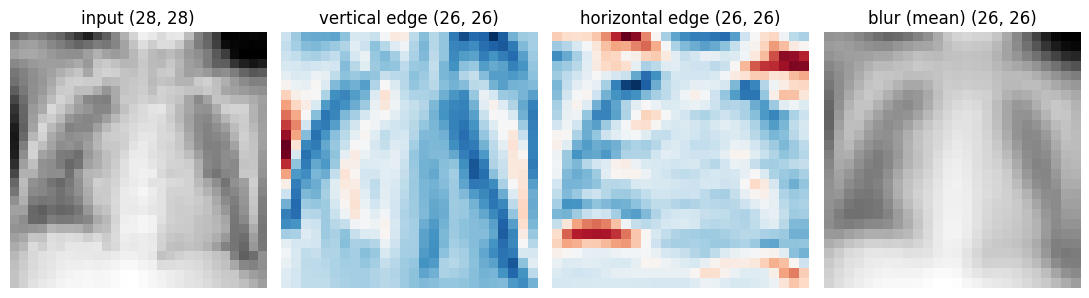

In [3]:
def conv2d(img, kernel, stride=1, padding=0):
    """Plain 2D convolution (cross-correlation, as in deep learning libraries)."""
    if padding > 0:
        img = np.pad(img, padding)                       # zero padding around the border
    k = kernel.shape[0]
    out_size = (img.shape[0] - k) // stride + 1
    out = np.zeros((out_size, out_size))
    for i in range(out_size):
        for j in range(out_size):
            patch = img[i * stride:i * stride + k, j * stride:j * stride + k]
            out[i, j] = np.sum(patch * kernel)           # multiply element-wise, then sum
    return out


kernels = {
    "vertical edge": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "horizontal edge": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
    "blur (mean)": np.ones((3, 3)) / 9,
}

if pneu is not None:
    xray = pneu["train_images"][0].astype(float) / 255.0
    fig, axes = plt.subplots(1, 4, figsize=(11, 3))
    axes[0].imshow(xray, cmap="gray")
    axes[0].set_title(f"input {xray.shape}")
    for ax, (name, k) in zip(axes[1:], kernels.items()):
        fmap = conv2d(xray, k)
        ax.imshow(fmap, cmap="RdBu_r" if "edge" in name else "gray")
        ax.set_title(f"{name} {fmap.shape}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

三張特徵圖都是 26×26：3×3 濾鏡在 28×28 的圖上只能放 26 個位置。垂直邊緣濾鏡在「左暗右亮」的地方輸出大正值（紅）、「左亮右暗」輸出負值（藍），所以肋骨、心臟與縱膈的左右邊界會被凸顯；模糊濾鏡則把每格換成鄰居的平均。

**重點：CNN 不需要我們手動設計這些濾鏡。** 濾鏡裡的 9 個數字就是權重，會像第 9 章一樣用反向傳播學出來。

### 1.1 步幅與填補決定輸出大小
輸出邊長 = (n + 2p − k) / s + 1，其中 n 是輸入邊長、k 是濾鏡大小、p 是填補（padding）、s 是步幅（stride）。

In [4]:
if pneu is not None:
    k = kernels["vertical edge"]
    for stride, padding in [(1, 0), (1, 1), (2, 0), (2, 1)]:
        out = conv2d(xray, k, stride=stride, padding=padding)
        formula = (28 + 2 * padding - 3) // stride + 1
        print(f"stride={stride}, padding={padding} -> output {out.shape}  (formula: {formula})")

stride=1, padding=0 -> output (26, 26)  (formula: 26)
stride=1, padding=1 -> output (28, 28)  (formula: 28)
stride=2, padding=0 -> output (13, 13)  (formula: 13)
stride=2, padding=1 -> output (14, 14)  (formula: 14)


`padding=1` 在外圍補一圈 0，讓輸出維持 28×28（Keras 寫作 `padding="same"`）；`stride=2` 一次跳兩格，輸出邊長大約減半。

### 1.2 最大池化：縮小影像、保留最強訊號
最大池化（max pooling）把影像切成 2×2 的小格，每格只留最大值，邊長減半。它沒有任何要學的權重。

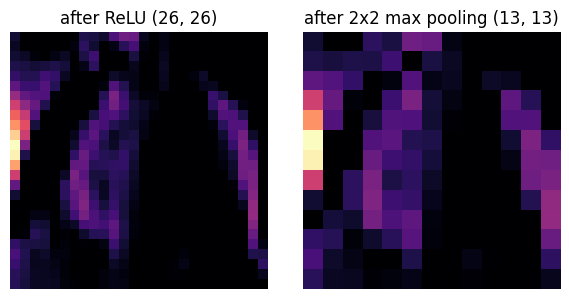

In [5]:
def max_pool(img, size=2):
    h, w = img.shape[0] // size, img.shape[1] // size
    return img[:h * size, :w * size].reshape(h, size, w, size).max(axis=(1, 3))


if pneu is not None:
    fmap = np.maximum(conv2d(xray, kernels["vertical edge"]), 0)   # ReLU: keep positive responses
    pooled = max_pool(fmap)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(fmap, cmap="magma")
    axes[0].set_title(f"after ReLU {fmap.shape}")
    axes[1].imshow(pooled, cmap="magma")
    axes[1].set_title(f"after 2x2 max pooling {pooled.shape}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

池化後只剩 13×13，但邊緣的大致位置仍看得出來。物體稍微平移一兩格，池化後的結果變化不大，這讓 CNN 對小幅位移比較不敏感。

## 2. 全連接網路 vs CNN：同一份胸部 X 光

先整理資料：全連接網路要把每張圖攤平成 784 個數字；CNN 則保留 28×28 的形狀，再加一個「通道」維度（灰階只有 1 個通道，彩色有 3 個）。

In [6]:
def prep(split, flat):
    X = pneu[f"{split}_images"].astype("float32") / 255.0
    X = X.reshape(-1, 28 * 28) if flat else X[..., None]          # (n, 784) or (n, 28, 28, 1)
    y = pneu[f"{split}_labels"].ravel().astype("float32")
    return X, y


ready = keras is not None and pneu is not None
if ready:
    Xf_tr, y_tr = prep("train", flat=True)
    Xf_va, y_va = prep("val", flat=True)
    Xf_te, y_te = prep("test", flat=True)
    Xi_tr, _ = prep("train", flat=False)
    Xi_va, _ = prep("val", flat=False)
    Xi_te, _ = prep("test", flat=False)
    print("flattened:", Xf_tr.shape, "| image-shaped:", Xi_tr.shape)
else:
    print("Skipped: Keras or the dataset is not available.")

flattened: (4708, 784) | image-shaped: (4708, 28, 28, 1)


### 2.1 對照組：第 9 章的全連接網路
架構、學習率、早停設定都和第 9 章相同。

In [7]:
EARLY = dict(monitor="val_loss", patience=5, restore_best_weights=True)

if ready:
    keras.utils.set_random_seed(RS)
    dense = keras.Sequential([
        keras.Input(shape=(28 * 28,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    dense.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    t0 = time.time()
    hist_dense = dense.fit(Xf_tr, y_tr, validation_data=(Xf_va, y_va),
                           epochs=30, batch_size=64, verbose=0,
                           callbacks=[keras.callbacks.EarlyStopping(**EARLY)])
    print(f"Dense: {dense.count_params():,} parameters, "
          f"{len(hist_dense.history['loss'])} epochs, {time.time() - t0:.1f} s")

Dense: 108,801 parameters, 13 epochs, 15.5 s


### 2.2 小型 CNN
兩組「卷積 → 池化」，最後攤平接一個 sigmoid 輸出。`Conv2D(16, 3)` 代表 16 個 3×3 濾鏡，會產生 16 張特徵圖。`model.summary()` 會列出每一層的輸出形狀與參數量。

In [8]:
if ready:
    keras.utils.set_random_seed(RS)
    cnn = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(16, 3, activation="relu"),   # 16 filters of 3x3 -> 26x26x16
        keras.layers.MaxPooling2D(2),                    # -> 13x13x16
        keras.layers.Conv2D(32, 3, activation="relu"),   # 32 filters of 3x3x16 -> 11x11x32
        keras.layers.MaxPooling2D(2),                    # -> 5x5x32
        keras.layers.Flatten(),                          # -> 800 numbers
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                loss="binary_crossentropy",
                metrics=["accuracy", keras.metrics.AUC(name="auc")])
    cnn.summary()
    print(f"Dense parameters: {dense.count_params():,} | CNN parameters: {cnn.count_params():,} "
          f"(ratio {dense.count_params() / cnn.count_params():.0f} : 1)")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,601 (21.88 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 0 (0.00 B)

Dense parameters: 108,801 | CNN parameters: 5,601 (ratio 19 : 1)


第一個卷積層只有 16 × (3×3 + 1) = 160 個參數：**同一個濾鏡在整張圖上重複使用**（權重共享），參數量跟影像大小無關。全連接網路的第一層光是 784 × 128 + 128 就超過 10 萬個參數。

接著訓練。CNN 每個 epoch 比全連接網路慢（要做很多次滑動相乘），為了控制執行時間，這裡最多訓練 15 個 epoch。

In [9]:
if ready:
    t0 = time.time()
    hist_cnn = cnn.fit(Xi_tr, y_tr, validation_data=(Xi_va, y_va),
                       epochs=15, batch_size=64, verbose=2,
                       callbacks=[keras.callbacks.EarlyStopping(**EARLY)])
    print(f"CNN: {len(hist_cnn.history['loss'])} epochs, {time.time() - t0:.1f} s")

Epoch 1/15


74/74 - 8s - 113ms/step - accuracy: 0.7483 - auc: 0.7146 - loss: 0.5278 - val_accuracy: 0.8034 - val_auc: 0.9330 - val_loss: 0.4380


Epoch 2/15


74/74 - 1s - 20ms/step - accuracy: 0.8505 - auc: 0.9197 - loss: 0.3456 - val_accuracy: 0.8664 - val_auc: 0.9497 - val_loss: 0.2854


Epoch 3/15


...

Epoch 14/15


74/74 - 2s - 21ms/step - accuracy: 0.9365 - auc: 0.9797 - loss: 0.1588 - val_accuracy: 0.9580 - val_auc: 0.9880 - val_loss: 0.1351


Epoch 15/15


74/74 - 1s - 19ms/step - accuracy: 0.9422 - auc: 0.9832 - loss: 0.1469 - val_accuracy: 0.9523 - val_auc: 0.9881 - val_loss: 0.1371


CNN: 15 epochs, 30.9 s


### 2.3 學習曲線
把兩個模型的驗證 AUC 畫在一起，並看 CNN 自己的訓練與驗證損失有沒有分岔。

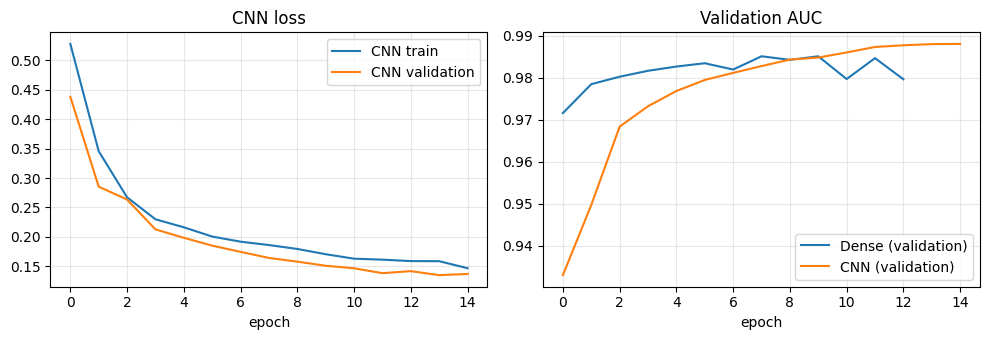

In [10]:
if ready:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(hist_cnn.history["loss"], label="CNN train")
    axes[0].plot(hist_cnn.history["val_loss"], label="CNN validation")
    axes[0].set_title("CNN loss")
    axes[1].plot(hist_dense.history["val_auc"], label="Dense (validation)")
    axes[1].plot(hist_cnn.history["val_auc"], label="CNN (validation)")
    axes[1].set_title("Validation AUC")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. 在同一份測試集上比較
最後才碰測試集（624 張）。除了 AUC，也報告敏感度、特異度，以及「全部猜肺炎」的多數類基準準確率。

In [11]:
def evaluate(p, y, threshold=0.5):
    tn, fp, fn, tp = confusion_matrix(y, (p > threshold).astype(int)).ravel()
    return {"accuracy": (tp + tn) / len(y), "AUC": roc_auc_score(y, p),
            "sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp)}


if ready:
    p_dense = dense.predict(Xf_te, verbose=0).ravel()
    p_cnn = cnn.predict(Xi_te, verbose=0).ravel()
    table = pd.DataFrame({"Dense (ch09)": evaluate(p_dense, y_te),
                          "CNN": evaluate(p_cnn, y_te)}).T
    table["parameters"] = [dense.count_params(), cnn.count_params()]
    print(table.round(3))
    print(f"majority-class baseline accuracy (always 'pneumonia'): {np.mean(y_te == 1):.3f}")

              accuracy    AUC  sensitivity  specificity  parameters
Dense (ch09)     0.829  0.916        0.982        0.573      108801
CNN              0.861  0.929        0.962        0.692        5601
majority-class baseline accuracy (always 'pneumonia'): 0.625


兩個模型的 AUC 差距多大才算數？測試集只有 624 張，我們用**配對自助法（paired bootstrap）**：從測試集有放回地重抽 624 張、兩個模型在同一批圖上各算一次 AUC，重複 1,000 次，看差值的分布。

In [12]:
if ready:
    rng = np.random.default_rng(RS)
    diffs = []
    for _ in range(1000):
        idx = rng.integers(0, len(y_te), len(y_te))
        if len(np.unique(y_te[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y_te[idx], p_cnn[idx]) - roc_auc_score(y_te[idx], p_dense[idx]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    print(f"AUC difference (CNN - Dense): {roc_auc_score(y_te, p_cnn) - roc_auc_score(y_te, p_dense):.3f} "
          f"(bootstrap 95% CI {lo:.3f} to {hi:.3f})")

AUC difference (CNN - Dense): 0.013 (bootstrap 95% CI 0.006 to 0.020)


解讀時請保守：

- 這個信賴區間只反映「測試集抽樣」的不確定性，**沒有包含換一個隨機種子重新訓練的變動**；換種子再訓練一次，差距可能變大或縮小。
- 測試集來自單一醫學中心、影像只有 28×28、沒有外部驗證。
- 比較合理的結論是：**CNN 用大約 1/20 的參數，在這份測試集上得到相近或略高的 AUC**，而不是「CNN 明顯比較好」。
- 兩個模型的特異度都偏低（把不少正常片判成肺炎），閾值 0.5 不一定適合臨床用途。

## 4. 打開 CNN 看看：濾鏡與特徵圖
第一個卷積層有 16 個 3×3 濾鏡。下面先把學到的權重畫出來，再看同一張 X 光經過這 16 個濾鏡後的特徵圖。

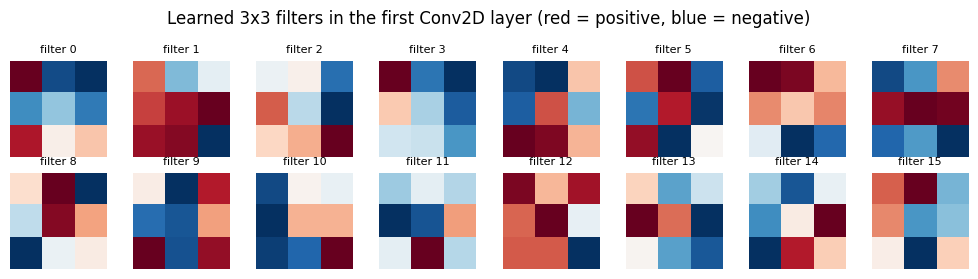

In [13]:
if ready:
    conv1 = cnn.layers[0]
    w = conv1.get_weights()[0]                  # shape (3, 3, 1, 16)
    fig, axes = plt.subplots(2, 8, figsize=(10, 2.8))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(w[:, :, 0, i], cmap="RdBu_r")
        ax.set_title(f"filter {i}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Learned 3x3 filters in the first Conv2D layer (red = positive, blue = negative)")
    plt.tight_layout()
    plt.show()

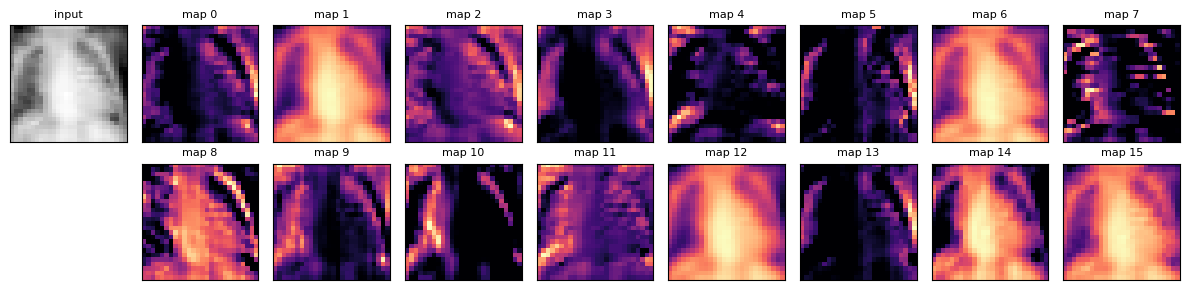

In [14]:
if ready:
    sample = Xi_te[y_te == 1][:1]                                  # one pneumonia image from the test set
    fmaps = keras.ops.convert_to_numpy(conv1(sample))[0]          # (26, 26, 16)
    fig, axes = plt.subplots(2, 9, figsize=(12, 3))
    axes[0, 0].imshow(sample[0, :, :, 0], cmap="gray")
    axes[0, 0].set_title("input", fontsize=8)
    axes[1, 0].axis("off")
    for i in range(16):
        ax = axes.ravel()[i + 1 + (i >= 8)]
        ax.imshow(fmaps[:, :, i], cmap="magma")
        ax.set_title(f"map {i}", fontsize=8)
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

有些特徵圖凸顯邊緣、有些凸顯整體亮度或某個方向的紋理。第一層學到的多半是這類低階特徵；越往後的層，特徵越抽象、越難用肉眼解讀。

要提醒的是：**「看起來像邊緣偵測」不代表模型的判斷理由就是醫學上合理的**。模型也可能學到與疾病無關的線索（例如影像來源、標記文字），第 13 章會用 Grad-CAM 進一步檢查。

## 5. 練習：多類別 CNN——BloodMNIST 8 種血球（建議開 GPU，可跳過）
BloodMNIST（CC BY 4.0）是周邊血液抹片的單一細胞彩色影像（28×28×3），共 8 類。和二元分類相比只改兩處：輸出層改成 8 個神經元＋ softmax，損失改成 `sparse_categorical_crossentropy`。

> 這一節要下載約 35 MB，訓練也是本 notebook 最久的部分。Colab 免費 CPU 若太慢，可以開 GPU，或把 `RUN_BLOOD` 改成 `False` 跳過。

In [15]:
RUN_BLOOD = True
BLOOD_CLASSES = ["basophil", "eosinophil", "erythroblast", "immature gran.",
                 "lymphocyte", "monocyte", "neutrophil", "platelet"]

blood = load_medmnist("bloodmnist", 35) if (RUN_BLOOD and keras is not None) else None
if blood is not None:
    Xb_tr = blood["train_images"].astype("float32") / 255.0
    yb_tr = blood["train_labels"].ravel()
    Xb_va = blood["val_images"].astype("float32") / 255.0
    yb_va = blood["val_labels"].ravel()
    Xb_te = blood["test_images"].astype("float32") / 255.0
    yb_te = blood["test_labels"].ravel()
    print("train", Xb_tr.shape, "| test", Xb_te.shape)
    print(pd.Series(np.bincount(yb_tr), index=BLOOD_CLASSES, name="train count"))

train (11959, 28, 28, 3) | test (3421, 28, 28, 3)
basophil           852
eosinophil        2181
erythroblast      1085
immature gran.    2026
lymphocyte         849
monocyte           993
neutrophil        2330
platelet          1643
Name: train count, dtype: int64


In [16]:
if blood is not None:
    keras.utils.set_random_seed(RS)
    blood_cnn = keras.Sequential([
        keras.Input(shape=(28, 28, 3)),                  # 3 color channels
        keras.layers.Conv2D(16, 3, activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(32, 3, activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(8, activation="softmax"),     # one probability per class, summing to 1
    ])
    blood_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist_blood = blood_cnn.fit(Xb_tr, yb_tr, validation_data=(Xb_va, yb_va),
                               epochs=5, batch_size=128, verbose=2)
    print(f"BloodMNIST CNN: {blood_cnn.count_params():,} parameters, {time.time() - t0:.1f} s")
else:
    print("Skipped BloodMNIST section.")

Epoch 1/5


94/94 - 5s - 56ms/step - accuracy: 0.4333 - loss: 1.5617 - val_accuracy: 0.7050 - val_loss: 0.9649


Epoch 2/5


94/94 - 3s - 30ms/step - accuracy: 0.6642 - loss: 0.9413 - val_accuracy: 0.7447 - val_loss: 0.7619


Epoch 3/5


...

Epoch 4/5


94/94 - 3s - 31ms/step - accuracy: 0.7531 - loss: 0.7110 - val_accuracy: 0.7874 - val_loss: 0.5998


Epoch 5/5


94/94 - 3s - 33ms/step - accuracy: 0.7707 - loss: 0.6574 - val_accuracy: 0.8002 - val_loss: 0.5580


BloodMNIST CNN: 11,496 parameters, 17.3 s


用混淆矩陣看哪些細胞最容易被搞混。每一列是真實類別、每一行是預測類別，對角線是答對的數量。

test accuracy: 0.793 | majority-class baseline: 0.195
softmax output of the first test image (sums to 1): [0.032 0.001 0.002 0.742 0.002 0.219 0.002 0.   ] sum = 1.0


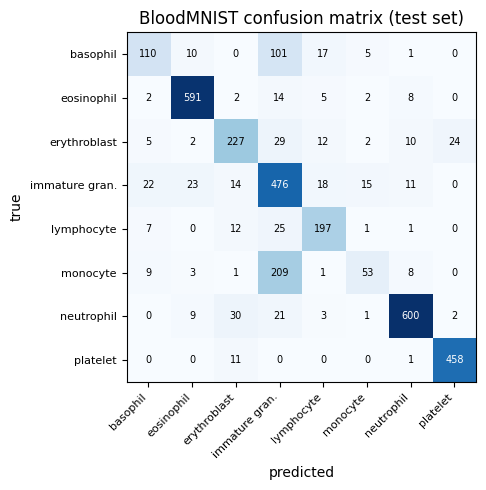

basophil          0.451
eosinophil        0.947
erythroblast      0.730
immature gran.    0.822
lymphocyte        0.811
monocyte          0.187
neutrophil        0.901
platelet          0.974
Name: per-class sensitivity (recall), dtype: float64


In [17]:
if blood is not None:
    pb = blood_cnn.predict(Xb_te, verbose=0)
    pred_b = pb.argmax(axis=1)
    print(f"test accuracy: {np.mean(pred_b == yb_te):.3f} | "
          f"majority-class baseline: {np.bincount(yb_te).max() / len(yb_te):.3f}")
    print("softmax output of the first test image (sums to 1):", pb[0].round(3), "sum =", round(float(pb[0].sum()), 3))
    cm = confusion_matrix(yb_te, pred_b)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(8), BLOOD_CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(8), BLOOD_CLASSES, fontsize=8)
    for i in range(8):
        for j in range(8):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title("BloodMNIST confusion matrix (test set)")
    plt.tight_layout()
    plt.show()
    recall = cm.diagonal() / cm.sum(axis=1)
    print(pd.Series(recall, index=BLOOD_CLASSES, name="per-class sensitivity (recall)").round(3))

只訓練 5 個 epoch 的小 CNN 就有不錯的整體準確率，但各類別差異很大：在我們的實測中，血小板、嗜酸性球、嗜中性球的敏感度都在 0.9 左右或更高，單核球（monocyte）卻不到 0.2、嗜鹼性球（basophil）不到 0.5，常被判成未成熟顆粒球等其他白血球（你的數字會因版本與硬體略有不同）。整體準確率會掩蓋這種「某幾類特別差」的情況，所以多類別問題要看混淆矩陣與各類別的敏感度。同樣地，這是 28×28 小圖、單一來源的教學結果，不能推論到實際血液抹片判讀。

## 6. 動手試試
1. 第 1 節：自己設計一個 3×3 濾鏡（例如對角線邊緣 `[[0,1,2],[-1,0,1],[-2,-1,0]]`），看看特徵圖凸顯了什麼。
2. 第 2.2 節：把 `Conv2D(16, 3)` 改成 `Conv2D(4, 3)` 或 `Conv2D(64, 3)`，比較參數量與測試 AUC；再試著把 `MaxPooling2D` 拿掉，參數量會怎麼變？為什麼？
3. 第 3 節：把 `evaluate` 的 `threshold` 從 0.5 改成 0.8，CNN 的敏感度與特異度如何交換？
4. 第 5 節：把 `epochs` 改成 15、加上 EarlyStopping，看哪幾類細胞進步最多。